In [5]:
import scanpy as sc
import pandas as pd

adata = sc.read_h5ad('/Users/renegibson/Downloads/IDC_cape.h5ad')
print(adata)

# Filter low-confidence sites
sc.pp.filter_genes(adata, min_cells=3)
print(f"\nAfter filter: {adata.n_obs} cells × {adata.n_vars} sites")

# CE sites
ce = adata[:, adata.var['site_type'] == 'CE']
print(f"\nCE sites: {ce.n_vars:,}")

# Top CE sites by total counts
import numpy as np
totals = np.array(ce.X.sum(axis=0)).flatten()
top = pd.Series(totals, index=ce.var_names).nlargest(20)
print("\nTop 20 CE sites:")
print(top)

AnnData object with n_obs × n_vars = 5680 × 21087
    var: 'gene', 'chrom', 'strand', 'rep_coord', 'site_type', 'pas_signal', 'feature_types', 'label', 'clinical_relevance'

After filter: 5680 cells × 21087 sites

CE sites: 7,138

Top 20 CE sites:
FTH1_CE61         152050.0
FTH1_CE44         118477.0
B2M_CE345         108849.0
NTS_CE26          105849.0
EEF1A1_CE43        76289.0
NTS_CE58           74359.0
RPL26_CE4          44339.0
RPS27_CE18         41390.0
HSP90AA1_CE180     40566.0
RPLP1_CE31         38593.0
CLEC3A_CE254       35317.0
RPS15A_CE8         35012.0
RPS23_CE150        31282.0
RPL23A_CE27        31063.0
MGST1_CE178        30082.0
DUSP1_CE102        27347.0
RPS10_CE15         25718.0
B2M_CE429          24112.0
JUN_CE167          23691.0
RPL37_CE193        22675.0
dtype: float32


In [6]:
import scanpy as sc
import pandas as pd
import numpy as np

adata = sc.read_h5ad('/Users/renegibson/Downloads/IDC_cape.h5ad')
ce = adata[:, adata.var['site_type'] == 'CE']

# Total CE reads per gene
ce_by_gene = ce.var.groupby('gene').apply(
    lambda x: ce[:, x.index].X.sum()
).reset_index()
ce_by_gene.columns = ['gene', 'ce_total']

# 看看有沒有breast cancer相關的gene
bc_genes = ['BRCA1', 'BRCA2', 'ESR1', 'ERBB2', 'PIK3CA', 
            'TP53', 'CDH1', 'MYC', 'PTEN', 'AKT1']

print("Breast cancer genes CE sites:")
bc_ce = ce.var[ce.var['gene'].isin(bc_genes)]
if len(bc_ce) > 0:
    for gene in bc_genes:
        sites = ce.var[ce.var['gene'] == gene]
        if len(sites) > 0:
            total = ce[:, sites.index].X.sum()
            print(f"  {gene}: {len(sites)} CE sites, {int(total):,} total reads")

/var/folders/zw/020w84513xl1z5hysj_t5k000000gn/T/ipykernel_99937/1627321960.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ce_by_gene = ce.var.groupby('gene').apply(


Breast cancer genes CE sites:
  BRCA1: 1 CE sites, 54 total reads
  ESR1: 8 CE sites, 3,121 total reads
  AKT1: 1 CE sites, 225 total reads


/var/folders/zw/020w84513xl1z5hysj_t5k000000gn/T/ipykernel_99937/1627321960.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ce_by_gene = ce.var.groupby('gene').apply(


In [8]:
esr1_ce = ce.var[ce.var['gene'] == 'ESR1'].copy()
esr1_ce['total_reads'] = [int(ce[:, sid].X.sum()) for sid in esr1_ce.index]
print(esr1_ce[['rep_coord', 'pas_signal', 'total_reads']].sort_values('total_reads', ascending=False))

            rep_coord pas_signal  total_reads
ESR1_CE299  152103175     AATGAA         1169
ESR1_CE284  152103022     GATAAA          762
ESR1_CE159  152101148     AATGAA          493
ESR1_CE115  152100601     AACAAA          408
ESR1_CE94   152099583     AATACA           97
ESR1_CE125  152100938     AATATA           69
ESR1_CE55   151880720     GATAAA           68
ESR1_CE194  152101408     AACAAA           55


In [9]:
# ESR1基因的結構
# ESR1在chr6，minus strand
# CE299在152103175

# 看這個位置是哪個intron
print(ce.var.loc['ESR1_CE299'])

# 有多少cells表現這個site
cells_with_ce299 = (ce[:, 'ESR1_CE299'].X > 0).sum()
print(f"\nCells with ESR1_CE299: {cells_with_ce299} / {ce.n_obs}")

gene                       ESR1
chrom                      chr6
strand                        +
rep_coord             152103175
site_type                    CE
pas_signal               AATGAA
feature_types           IsoCAPE
label                   unknown
clinical_relevance            —
Name: ESR1_CE299, dtype: object

Cells with ESR1_CE299: 899 / 5680


In [10]:
# 查文獻ESR1 exon結構
# ESR1 exons (GRCh38, + strand):
# Exon 6 ends ~152,101,xxx
# Intron 6: ~152,101,xxx - 152,103,xxx
# Exon 7 starts ~152,103,xxx

# CE299 at 152,103,175 → intron 6/7 junction附近

# 看CE299附近的其他sites
nearby = ce.var[
    (ce.var['gene'] == 'ESR1') & 
    (ce.var['rep_coord'] > 152100000) &
    (ce.var['rep_coord'] < 152105000)
].copy()
nearby['total_reads'] = [int(ce[:, sid].X.sum()) for sid in nearby.index]
print(nearby[['rep_coord', 'pas_signal', 'total_reads']].sort_values('rep_coord'))

            rep_coord pas_signal  total_reads
ESR1_CE115  152100601     AACAAA          408
ESR1_CE125  152100938     AATATA           69
ESR1_CE159  152101148     AATGAA          493
ESR1_CE194  152101408     AACAAA           55
ESR1_CE284  152103022     GATAAA          762
ESR1_CE299  152103175     AATGAA         1169


In [12]:
cape = sc.read_h5ad('/Users/renegibson/Downloads/IDC_cape.h5ad')

# ESR1_CE299 per cell
esr1_ce299 = cape[:, 'ESR1_CE299'].X.toarray().flatten()
print(f"Cells with ESR1_CE299 > 0: {(esr1_ce299 > 0).sum()}")
print(f"Mean UMI per cell: {esr1_ce299[esr1_ce299 > 0].mean():.2f}")
print(f"Max UMI: {esr1_ce299.max():.0f}")

Cells with ESR1_CE299 > 0: 899
Mean UMI per cell: 1.30
Max UMI: 5


/Users/renegibson/miniforge3/envs/iso_decipher/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/renegibson/miniforge3/envs/iso_decipher/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loaded: 5680 cells × 36601 genes


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


After QC: 2366 cells
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.61
Detected doublet rate = 0.4%
Estimated detectable doublet fraction = 9.9%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.3%
Elapsed time: 1.6 seconds
After doublet removal: 2356 cells
Clusters: 9
Common cells: 2356


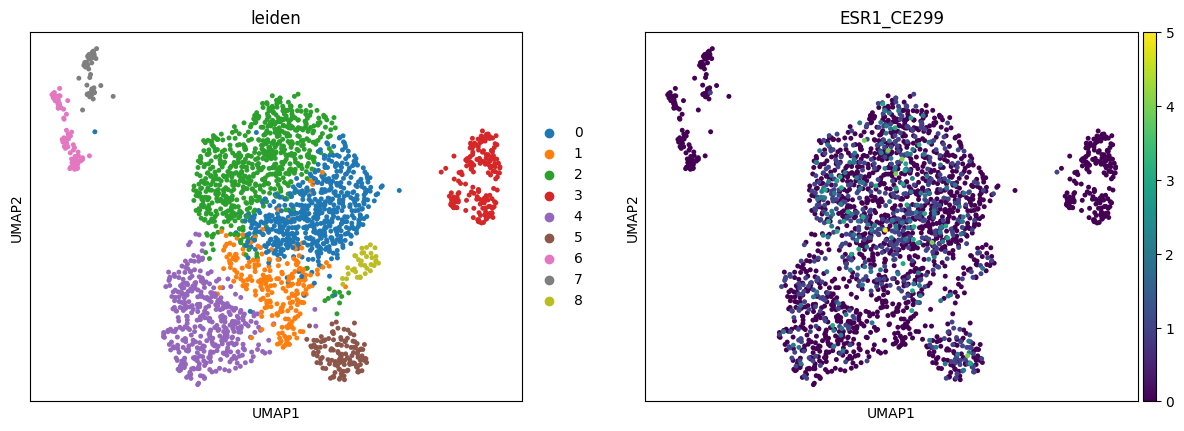

In [ ]:
# 先讀H5建GEX object
import scanpy as sc
import pandas as pd
import numpy as np

# 讀IDC的GEX h5
adata_gex = sc.read_10x_h5(
    '/Users/renegibson/Downloads/Breast_Cancer_3p_filtered_feature_bc_matrix.h5',
    gex_only=True
)
adata_gex.var_names_make_unique()
print(f"Loaded: {adata_gex.n_obs} cells × {adata_gex.n_vars} genes")

# QC
adata_gex.var['mt'] = adata_gex.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata_gex, qc_vars=['mt'], inplace=True)

# Filter
adata_gex = adata_gex[
    (adata_gex.obs['pct_counts_mt'] < 10) &
    (adata_gex.obs['n_genes_by_counts'] > 200) &
    (adata_gex.obs['total_counts'] > 500)
].copy()
print(f"After QC: {adata_gex.n_obs} cells")

# Scrublet
import scrublet as scr
scrub = scr.Scrublet(adata_gex.X)
doublet_scores, predicted_doublets = scrub.scrub_doublets()
adata_gex.obs['doublet_score'] = doublet_scores
adata_gex.obs['predicted_doublet'] = predicted_doublets
adata_gex = adata_gex[~adata_gex.obs['predicted_doublet']].copy()
print(f"After doublet removal: {adata_gex.n_obs} cells")

# Normalize + cluster
sc.pp.normalize_total(adata_gex, target_sum=1e4)
sc.pp.log1p(adata_gex)
adata_gex.raw = adata_gex

sc.pp.highly_variable_genes(adata_gex, n_top_genes=2000)
sc.pp.pca(adata_gex)
sc.pp.neighbors(adata_gex)
sc.tl.umap(adata_gex)
sc.tl.leiden(adata_gex, resolution=0.5, flavor='igraph',
             directed=False, n_iterations=2)

print(f"Clusters: {adata_gex.obs['leiden'].nunique()}")

# 把ESR1_CE299加進obs
cape = sc.read_h5ad('/Users/renegibson/Downloads/IDC_cape.h5ad')
common_cells = adata_gex.obs_names.intersection(cape.obs_names)
print(f"Common cells: {len(common_cells)}")

esr1_ce299 = pd.Series(
    cape[common_cells, 'ESR1_CE299'].X.toarray().flatten(),
    index=common_cells
)
adata_gex.obs['ESR1_CE299'] = esr1_ce299.reindex(adata_gex.obs_names).fillna(0)

sc.pl.umap(adata_gex, color=['leiden', 'ESR1','ESR1_CE299'], ncols=3)


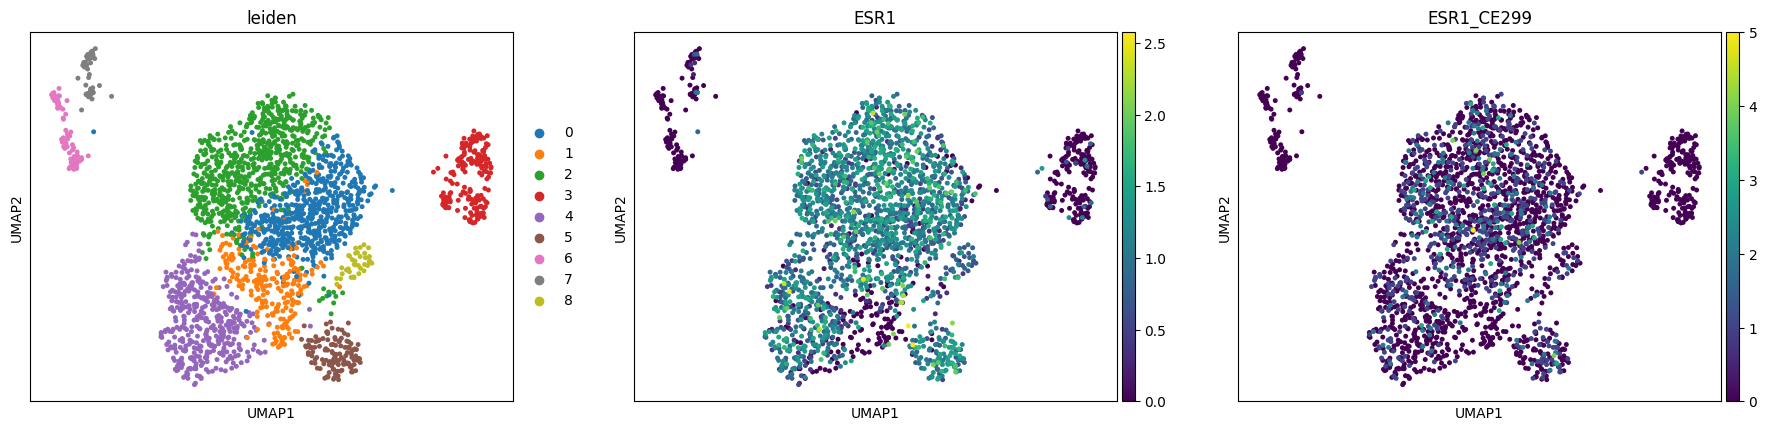

In [14]:
sc.pl.umap(adata_gex, color=['leiden', 'ESR1','ESR1_CE299'], ncols=3)


ESR1+ cells: 1899
CE299/ESR1 ratio stats:
count    1899.000000
mean        0.400461
std         0.654727
min         0.000000
25%         0.000000
50%         0.000000
75%         0.771825
max         4.237133
dtype: float64


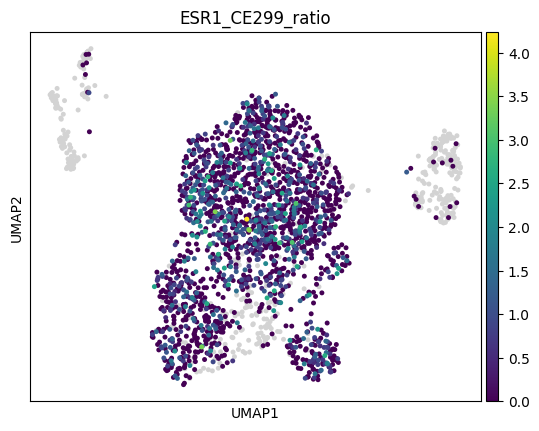

In [15]:
# 在ESR1表現的cells裡
# CE299 UMI / ESR1 total UMI
# 如果是真實的CE site → 這個比例在某些cells特別高
# 如果是background → 這個比例在所有cells都很低且一致

esr1_expr = adata_gex[:, 'ESR1'].X.toarray().flatten()
ce299 = adata_gex.obs['ESR1_CE299'].values

# 只看有ESR1表現的cells
mask = esr1_expr > 0
ratio = np.where(mask, ce299 / (esr1_expr + 1e-6), np.nan)

adata_gex.obs['ESR1_CE299_ratio'] = ratio

print(f"ESR1+ cells: {mask.sum()}")
print(f"CE299/ESR1 ratio stats:")
print(pd.Series(ratio[mask]).describe())

sc.pl.umap(adata_gex, color='ESR1_CE299_ratio')

In [16]:
# 看ratio高的cells的ESR1 GEX
high_ratio = adata_gex.obs['ESR1_CE299_ratio'] > 2

print(f"High ratio cells (>2): {high_ratio.sum()}")
print(f"\nESR1 GEX in high ratio cells:")
print(pd.Series(esr1_expr[high_ratio]).describe())
print(f"\nESR1 GEX in normal cells:")
print(pd.Series(esr1_expr[~high_ratio & mask]).describe())

High ratio cells (>2): 65

ESR1 GEX in high ratio cells:
count    65.000000
mean      0.918176
std       0.396716
min       0.236008
25%       0.497535
50%       0.899215
75%       1.223888
max       1.986512
dtype: float64

ESR1 GEX in normal cells:
count    1834.000000
mean        1.065093
std         0.391619
min         0.148581
25%         0.794430
50%         1.056952
75%         1.341335
max         2.577596
dtype: float64


In [18]:

esr1_pos = adata_gex.obs_names[esr1_expr > 0]
ce299_vals = adata_gex.obs['ESR1_CE299'].values

mask_esr1 = esr1_expr > 0
mask_ce299_pos = (adata_gex.obs['ESR1_CE299'].values > 0) & mask_esr1
mask_ce299_neg = (adata_gex.obs['ESR1_CE299'].values == 0) & mask_esr1

print(f"ESR1+ CE299+: {mask_ce299_pos.sum()}")
print(f"ESR1+ CE299-: {mask_ce299_neg.sum()}")

# 加label
adata_gex.obs['ESR1_CE299_group'] = 'other'
adata_gex.obs.loc[mask_ce299_pos, 'ESR1_CE299_group'] = 'ESR1+_CE299+'
adata_gex.obs.loc[mask_ce299_neg, 'ESR1_CE299_group'] = 'ESR1+_CE299-'

# DEG between two groups
import scanpy as sc
sc.tl.rank_genes_groups(
    adata_gex, 
    groupby='ESR1_CE299_group',
    groups=['ESR1+_CE299+'],
    reference='ESR1+_CE299-',
    method='wilcoxon',
    use_raw=True
)

result = sc.get.rank_genes_groups_df(adata_gex, group='ESR1+_CE299+').head(50)
print(result[['names', 'logfoldchanges', 'pvals_adj']])

ESR1+ CE299+: 641
ESR1+ CE299-: 1258
         names  logfoldchanges     pvals_adj
0         ESR1        0.519691  3.515372e-31
1        RPS17        0.318472  3.430463e-08
2         GOT2        0.412721  7.351803e-08
3        NTRK2        0.388203  3.242873e-07
4        H2AFY        0.257118  6.835990e-07
5        KRT15        0.575732  1.768850e-06
6       RPL13A        0.244691  4.155112e-06
7          DBI        0.235813  9.243643e-06
8          SCD        0.367860  9.436548e-06
9         MSI2        0.316074  9.436548e-06
10        NFIX        0.319526  1.296830e-05
11     ALDH6A1        0.451749  1.296830e-05
12    PLA2G12A        0.285921  1.296830e-05
13       MAGI2        0.349974  1.296830e-05
14         DSP        0.441343  1.311842e-05
15        SMC4        0.441944  2.567779e-05
16      SMIM14        0.291291  2.596095e-05
17        MDM2        0.382084  2.596095e-05
18       PARP1        0.289416  3.050700e-05
19      TGFBR3        0.385299  3.426611e-05
20       TRPS1    

In [20]:
# 看在相同ESR1 expression level的cells裡
# CE299+ vs CE299-是否還有差異
# 把ESR1 expression加進去控制

from scipy import stats

# 只在ESR1 expression level相似的cells裡比較
# 把ESR1 expression binned
adata_esr1 = adata_gex[mask_esr1].copy()
esr1_bins = pd.qcut(esr1_expr[mask_esr1], q=4, labels=['Q1','Q2','Q3','Q4'])
adata_esr1.obs['esr1_quartile'] = esr1_bins.to_numpy()
adata_esr1.obs['ce299_status'] = np.where(
    adata_esr1.obs['ESR1_CE299'] > 0, 'CE299+', 'CE299-'
)

# 看每個quartile的CE299比例
print(pd.crosstab(adata_esr1.obs['esr1_quartile'], 
                  adata_esr1.obs['ce299_status'], 
                  normalize='index').round(3))

ce299_status   CE299+  CE299-
esr1_quartile                
Q1              0.149   0.851
Q2              0.307   0.693
Q3              0.388   0.612
Q4              0.505   0.495


In [21]:
import sys
sys.path.insert(0, '/Users/renegibson/Desktop/githubrepo/IsoCAPE/IsoCAPE/scripts/annotator')
from gtf_parser import GTFParser

parser = GTFParser(
    gtf_path='/Users/renegibson/Desktop/githubrepo/IsoDecipher/data/Homo_sapiens.GRCh38.115.gtf',
    db_path='/Users/renegibson/Desktop/githubrepo/IsoDecipher/data/Homo_sapiens.GRCh38.115.gtf.db'
)
parser.build()

# 看interval格式
chrom = 'chr6'
strand = '+'
tree = parser.intron_trees[chrom][strand]
print(f"Sample intervals:")
for iv in tree._intervals[:3]:
    print(iv)

[GTFParser] Loading from DB: /Users/renegibson/Desktop/githubrepo/IsoDecipher/data/Homo_sapiens.GRCh38.115.gtf.db
  [GTFParser] 50,000 transcripts loaded ...
  [GTFParser] 100,000 transcripts loaded ...
  [GTFParser] 150,000 transcripts loaded ...
  [GTFParser] 200,000 transcripts loaded ...
  [GTFParser] 250,000 transcripts loaded ...
[GTFParser] Loaded 293,596 transcripts from DB
[GTFParser] Building indexes ...
[GTFParser] Building interval trees ...
[GTFParser] Done. 293,596 known 3' ends | 2,635,718 introns indexed
Sample intervals:
(17281749, 17282804, ('RBM24', 'ENST00000379052'))
(17282928, 17284656, ('RBM24', 'ENST00000379052'))
(17284711, 17291755, ('RBM24', 'ENST00000379052'))


In [22]:
from collections import defaultdict

# 計算每個gene的total unique intron length（去除overlap）
gene_intron_coords = defaultdict(set)

for chrom, strands in parser.intron_trees.items():
    for strand, tree in strands.items():
        for (i_start, i_end, (gene, tx_id)) in tree._intervals:
            # 加進set避免重複計算同一個intron
            gene_intron_coords[gene].add((i_start, i_end))

# 計算每個gene的total intron length
gene_intron_length = {}
for gene, coords in gene_intron_coords.items():
    gene_intron_length[gene] = sum(e - s for s, e in coords)

print(f"Genes with intron annotation: {len(gene_intron_length):,}")
print(f"ESR1 total intron length: {gene_intron_length.get('ESR1', 0):,} bp")
print(f"FTH1 total intron length: {gene_intron_length.get('FTH1', 0):,} bp")

Genes with intron annotation: 19,088
ESR1 total intron length: 1,381,584 bp
FTH1 total intron length: 33,163 bp


In [28]:
# 重新算enrichment
from collections import defaultdict
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

# Step 1: 從parquet讀CE reads
pf = pq.ParquetFile('/Users/renegibson/Downloads/IDC_cryptic.parquet')

site_reads = defaultdict(int)
site_gene  = {}

for batch in pf.iter_batches(batch_size=1_000_000):
    df = batch.to_pandas()
    ce = df[df['site_type'] == 'CE']
    for row in ce.itertuples(index=False):
        site_reads[row.site_id] += 1
        site_gene[row.site_id]   = row.gene

# Step 2: gene total CE reads
gene_total_reads = defaultdict(int)
for sid, n in site_reads.items():
    gene_total_reads[site_gene[sid]] += n

# Step 3: gene intron length（已經有parser了）
gene_intron_coords = defaultdict(set)
for chrom, strands in parser.intron_trees.items():
    for strand, tree in strands.items():
        for (i_start, i_end, (gene, tx_id)) in tree._intervals:
            gene_intron_coords[gene].add((i_start, i_end))

gene_intron_length = {
    gene: sum(e - s for s, e in coords)
    for gene, coords in gene_intron_coords.items()
}

# Step 4: enrichment
enrich_records = {}
for sid, n_reads in site_reads.items():
    gene       = site_gene[sid]
    total      = gene_total_reads[gene]
    intron_len = gene_intron_length.get(gene, 0)
    if intron_len == 0 or total == 0:
        continue
    expected = total * (10 / intron_len)
    enrich_records[sid] = {
        'gene':       gene,
        'n_reads':    n_reads,
        'expected':   expected,
        'enrichment': n_reads / expected,
    }

enrich_df = pd.DataFrame(enrich_records).T
enrich_df = enrich_df.astype({'n_reads': float, 'expected': float, 'enrichment': float})

# Step 5: 只看h5ad裡的CE sites（min_reads=50）
import scanpy as sc
cape = sc.read_h5ad('/Users/renegibson/Downloads/IDC_cape.h5ad')
ce_sites = cape.var[cape.var['site_type'] == 'CE'].index

enrich_filtered = enrich_df.loc[enrich_df.index.isin(ce_sites)].copy()
print(f"CE sites: {len(enrich_filtered):,}")
print(enrich_filtered['enrichment'].describe())

CE sites: 7,138
count      7138.000000
mean        778.943304
std        2397.682630
min           0.062774
25%          92.729521
50%         265.919617
75%         718.239605
max      136466.924157
Name: enrichment, dtype: float64


In [26]:
print(enrich_filtered[enrich_filtered['gene'] == 'ESR1'][
    ['gene', 'n_reads', 'expected', 'enrichment']
])

            gene  n_reads  expected   enrichment
ESR1_CE55   ESR1      9.0  0.023806   378.055822
ESR1_CE94   ESR1      7.0  0.023806   294.043417
ESR1_CE115  ESR1     53.0  0.023806  2226.328732
ESR1_CE125  ESR1     10.0  0.023806   420.062025
ESR1_CE159  ESR1     42.0  0.023806  1764.260505
ESR1_CE194  ESR1      8.0  0.023806   336.049620
ESR1_CE284  ESR1     62.0  0.023806  2604.384555
ESR1_CE299  ESR1    102.0  0.023806  4284.632654


In [27]:
cape = sc.read_h5ad('/Users/renegibson/Downloads/IDC_cape.h5ad')
cape.var['enrichment'] = enrich_filtered['enrichment'].reindex(cape.var_names)

# 存回去
cape.write_h5ad('/Users/renegibson/Downloads/IDC_cape.h5ad')
print("Saved with enrichment scores!")

# Top enriched CE sites by absolute reads AND enrichment
ce = cape[:, cape.var['site_type'] == 'CE']
totals = np.array(ce.X.sum(axis=0)).flatten()
ce.var['total_reads'] = totals

# 同時考慮兩個指標
ce.var['score'] = ce.var['enrichment'] * np.log1p(ce.var['total_reads'])
print(ce.var.nlargest(20, 'score')[['gene','total_reads','enrichment','score']])

Saved with enrichment scores!
                                 gene  total_reads     enrichment  \
FGF13_CE3                       FGF13        177.0  136466.924157   
SLC30A8_CE3                   SLC30A8        114.0   53642.400000   
RPS10-NUDT3_CE20          RPS10-NUDT3       1103.0   25123.243860   
JAK1_CE144                       JAK1        428.0   22284.374841   
LDLRAD4_CE110                 LDLRAD4         88.0   28961.452174   
RGS7_CE27                        RGS7         61.0   29635.699074   
SORBS2_CE73                    SORBS2        226.0   22541.796743   
ZBTB20_CE82                    ZBTB20         62.0   27938.479758   
RUNX1_CE125                     RUNX1       1155.0   15646.254592   
DISP1_CE15                      DISP1        171.0   20355.134021   
KCNJ15_CE19                    KCNJ15        328.0   16861.177711   
ENSG00000285708_CE35  ENSG00000285708        170.0   18989.056015   
DENND2B_CE69                  DENND2B        195.0   18415.606278   
MRPS

/var/folders/zw/020w84513xl1z5hysj_t5k000000gn/T/ipykernel_99937/3762009539.py:11: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  ce.var['total_reads'] = totals


In [29]:
print(cape.var.loc['RUNX1_CE125'])

# 有多少cells
runx1_ce = cape[:, 'RUNX1_CE125'].X.toarray().flatten()
print(f"\nCells with RUNX1_CE125: {(runx1_ce > 0).sum()} / {cape.n_obs}")
print(f"Mean UMI: {runx1_ce[runx1_ce > 0].mean():.2f}")

gene                         RUNX1
chrom                        chr21
strand                           -
rep_coord                 34887458
site_type                       CE
pas_signal                  TATAAA
feature_types              IsoCAPE
label                      unknown
clinical_relevance               —
enrichment            15646.254592
Name: RUNX1_CE125, dtype: object

Cells with RUNX1_CE125: 879 / 5680
Mean UMI: 1.31
